# 🎓 **Homework #2** 🎓

---

### 👤 **Assigner**:  
**Malkova Ksenia**

### ✍️ **Contacts**:  
- [kemalkova@edu.hse.ru](mailto:kemalkova@edu.hse.ru)

- [@ksu_marshmallow](https://t.me/ksu_marshmallow)

### 🔥 **Deadline** 🔥:  
- **18.02.2025**
---

In [38]:
import warnings
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", context="notebook", palette="pastel")
warnings.simplefilter('ignore')

In [39]:
DATA_FOLDER = Path.home() / 'PopGen_Models/data/HW2'
SCRIPT_FOLDER = Path.home() / 'PopGen_Models/scripts'
SEED = 42

## 🧬 Task 1

>Митохондриальная ДНК наследуется исключительно от матери. Если ее использовать для построения дерева, связывающего большое количество людей из разных этнических групп, то ее корень будет представлять "мать-прародительницу" (или **митохондриальная Ева**), от которой мы все унаследовали наши митохондрии.Кластеризация этнических групп на таком дереве может дать представление о физическом месторасположении Евы. 
>
>В работе Канна, Стоункинга и Уилсона утверждалось, что Ева находится в Африке (что поддерживает теорию происхождения человека из Африки). Было построено корневое дерево, которое показывало связи между 147 людьми. Оцените, *сколько топологически различных деревьев нужно было рассмотреть, если бы каждая возможность была действительно исследована* (Порядок величины количества различный деревьев на 147 листьях)

Количество топологически различных **укорененных бинарных деревьев** с $n$ листьями:

$$
T(n) = (2n - 3)!!
$$

По условию задачи (статьи) листьев 147 ($n = 147$). Таким образом, количество различных деревьев равно:

$$
T(147) = (2 \cdot 147 - 3)!! = 291!!
$$

Чтобы оценить порядок этой величины, **оценим ее асимптотически**. Для нечетных $n$ двойной факториал можно [приближенно вычислить](https://en.wikipedia.org/wiki/Double_factorial) как (с приближением Стирлинга):

$$
m !! = \sqrt{2m} \left(\frac{m}{e} \right)^{m/2} = \sqrt{\frac{2}{e^m}} \cdot m^{\frac{m+1}{2}}
$$

Нам нужно оценить порядок, поэтому наложим натуральный логарифм:

$$
\ln{m!!} = \frac{1}{2} \cdot \ln{2} - \frac{m}{2} + \frac{m+1}{2} \cdot \ln{m}
$$

Подставляем $m = 2n-3 = 291$:

$$\ln{T(n)} = \frac{1}{2} \cdot \ln{2} - \frac{291}{2} + 146 \cdot \ln{291} \approx 683$$

Теперь переходим для удобства к десятичному логарифму:

$$\log_{10} T(n) = \frac{683}{\ln{10}} \approx \frac{683}{2.3026} \approx 297$$


Таким образом, количество топологически различных укорененных бинарных деревьев с 147 листьями имеет порядок величины:
$$
\boxed{10^{297}}
$$


Очень много!!! Для сравнения:
- $\sim 10^{17}$ сек - возраст Вселенной (13.8 млрд лет).
- $\sim 10^{80}$ - число атомов во Вселенной.
- $\sim 10^{120}$ - количество возможных шахматных партий.

Так что полный перебор всех возможных деревьев даже для такого (относительно) небольшого числа листьев практически невозможен :(

In [40]:
def calculate_approx_n_trees(n_leaves: int = 147):
    m = 2 * n_leaves - 3

    ln_order = 0.5 * np.log(2) - 0.5 * m + 0.5 * (m + 1) * np.log(m)
    log10_order = ln_order / np.log(10)

    return log10_order

n_leaves = 147
print(f"Approximate number of rooted trees with {n_leaves}: 10^{calculate_approx_n_trees(n_leaves):.0f}")

Approximate number of rooted trees with 147: 10^297


----

## 🧬 Task 2

>**1. Скачайте 1240К панель с сайта группы [David Reich](https://reich.hms.harvard.edu). Файлы `.geno`, `.ind`, `.snp` и `.anno`**

Скачала с гугл-диска (извиняюсь, при перезапуске уже и выходные файлы есть)

In [41]:
!ls {DATA_FOLDER}

parfile_french_fin_ngan      pops.1240K.modern.txt
parfile_french_mbuti_lezgin  v54.1.p1_HO_public.anno
parfile_mbuti_russia	     v54.1.p1_HO_public.geno
popfile_french_fin_ngan      v54.1.p1_HO_public.ind
popfile_french_mbuti_lezgin  v54.1.p1_HO_public.snp
popfile_mbuti_russia


<hr style="border: 1px dashed;">

>**2. Установить [AdmixTools](https://github.com/DReichLab/AdmixTools) (необходимо openblas, gsl)**

1. Устанавливаем зависимости

```bash
    sudo apt update
    sudo apt install -y libopenblas-dev libgsl-dev liblapacke-dev build-essential 
```

2. Клоним репу

```bash
    git clone https://github.com/DReichLab/AdmixTools.git
    cd AdmixTools
```

3. Компилируем

```bash
    cd src
    make clobber
    make install
```

Все скомпилированные программы находятся в директории `bin/`. 
- `convertf` - programs for converting file formats (**README.CONVERTF**)
- `qp3Pop` - running f_3 test. This test can be used as a format test of admixture with 3 populations (**README.3PopTest**)
- `qpBound` - running qpBound. This test can be used for estimating bounds on the admixture proportions, given 3 populations (2 reference and one target) (**README.3PopTest**)
- `qpDstat` - running D-statistics. This is a formal test of admixture with 4 populations (**README.Dstatistics**)
- `qpF4Ratio` - running F4 ratio estimation. This program computes the admixture proportion by taking the ratio of two f4 tests (**README.F4RatioTest**)
- `rolloff` - this program can be used for dating admixture events (**README.ROLLOFF**/ **README.ROLLOFF_OUTPUT**)

Пример использования:


```bash
    ./bin/qpDstat -p params.txt
```

Файл параметров (`params.txt`) должен содержать настройки для конкретного анализа. Подробнее о формате параметров смотрите в соответствующих README-файлах.

In [42]:
ADMIX_EXEC_PATH = Path.home() / 'PopGen_Models/AdmixTools/bin/'

<hr style="border: 1px dashed;">

>**3. Прочитайте [README.3PopTest](https://github.com/DReichLab/AdmixTools/blob/master/README.3PopTest), чтобы сделать файл с параметрами (туда пропишутся пути до файлов 1240К+ путь до файлов с популяциями).**

`parfile` должен содержать:
- **genotypename** - название файла с генотипами (eigenstrat format). Это наш `v54.1.p1_HO_public.geno`
- **snpname** - название файла с snp (название, частота альтернативного аллеля, позиция в геноме, референсный и альтернативный аллели) (eigenstrat format). Это наш `v54.1.p1_HO_public.snp`
- **indivname** - название файла с аннотацией образов (название образца, пол и популяция) (in eigenstrat format). Это наш `v54.1.p1_HO_public.ind`. 
- **popfilename** - название файла с интересуемым тройками, для которых хотим посчитать f3-статистику. Формата **<Source1 (A)> <Source2 (B)> < Target (C)>** построчно

Примерная структура парфайла:

```bash
    genotypename: DATA_FOLDER/v54.1.p1_HO_public.geno
    snpname: DATA_FOLDER/v54.1.p1_HO_public.snp
    indivname: DATA_FOLDER/v54.1.p1_HO_public.ind
    popfilename: DATA_FOLDER/popfile
```

In [43]:
def make_popfile(A: list, B: list, C: list,
                 popfilename: str = 'popfile',
                 data_folder: Path = Path('data')
                ):
    '''
    Function that create and save popfile that contains 3 populations on each line 
        <Source1 (A)> <Source2 (B)> < Target (C)>

    File will be saved as popfilename in data_folder
    '''
    
    if not (len(A)==len(B)==len(C)):
        raise ValueError(f"Lists must have the same length, but got: A={len(A)}, B={len(B)}, C={len(C)}")

    with open(data_folder / popfilename, 'w') as file:
        for i in range(len(A)):
            print(A[i], B[i], C[i], file=file)

    print(f'File "{popfilename}" saved in {data_folder}')

In [44]:
def make_parfile(parfilename: str = 'parfile',
                 genotypename: str = 'v54.1.p1_HO_public.geno',
                 snpname: str = 'v54.1.p1_HO_public.snp',
                 indivname: str = 'v54.1.p1_HO_public.ind',
                 popfilename: str = 'popfile',
                 data_folder: Path = Path('data'),
                ):   # это я

    with open(data_folder / parfilename, 'w') as file:
        print(f"genotypename: {data_folder / genotypename}", file=file)
        print(f"snpname: {data_folder / snpname}", file=file)
        print(f"indivname: {data_folder / indivname}", file=file)
        print(f"popfilename: {data_folder / popfilename}", file=file)

    print(f'File "{parfilename}" saved in {data_folder}')

<hr style="border: 1px dashed;">

>**4. С помощью f3 статистики с внешней группой `Mbuti` будем тестировать, кто ближе к русским `Russia`. HO в популяционном смысле. Для этого изучите файл `.anno` и выберите 5 ваших "любимых" СОВРЕМЕННЫХ неафриканских популяций. Посчитайте статистику**
>$$f_3 (\text{Mbuti.HO}; \text{Russian.HO}, \text{Pop})$$
>**Сравните их между собой. Согласуются ли полученные результаты с общеизвестными представлениями?**
>
>**P.S.** Обратите внимание, что
>$$f_3^{admixtools} (X_1, X_2; X_3) = f_3 (X_3; X_1, X_2)$$

In [45]:
EXEC_F3_PATH = (ADMIX_EXEC_PATH / 'qp3Pop').as_posix()
EXEC_F3_PATH

'/home/ksu_marshmallow/PopGen_Models/AdmixTools/bin/qp3Pop'

Смотрим на популяции в `.anno`

In [46]:
BASENAME = 'v54.1.p1_HO_public'

annot = pd.read_csv(DATA_FOLDER / f"{BASENAME}.anno", sep='\t')

print(annot.shape)
annot.head()

(20502, 35)


,Genetic ID,Master ID,Skeletal code,Skeletal element,"Year data from this individual was first published [for a present-day individuals we give the data of the data reported here; missing GreenScience 2010 (Vi33.15, Vi33.26), Olalde2018 (I2657), RasmussenNature2010 (Australian)]",Publication,"Method for Determining Date; unless otherwise specified, calibrations use 95.4% intervals from OxCal v4.4.2 Bronk Ramsey (2009); r5; Atmospheric data from Reimer et al (2020)","Date mean in BP in years before 1950 CE [OxCal mu for a direct radiocarbon date, and average of range for a contextual date]","Date standard deviation in BP [OxCal sigma for a direct radiocarbon date, and standard deviation of the uniform distribution between the two bounds for a contextual date]","Full Date One of two formats. (Format 1) 95.4% CI calibrated radiocarbon age (Conventional Radiocarbon Age BP, Lab number) e.g. 2624-2350 calBCE (3990±40 BP, Ua-35016). (Format 2) Archaeological context range, e.g. 2500-1700 BCE",...,Y haplogroup (manual curation in ISOGG format),mtDNA coverage (merged data),mtDNA haplogroup if >2x or published,mtDNA match to consensus if >2x (merged data),Damage rate in first nucleotide on sequences overlapping 1240k targets (merged data),Sex ratio [Y/(Y+X) counts] (merged data),"Library type (minus=no.damage.correction, half=damage.retained.at.last.position, plus=damage.fully.corrected, ds=double.stranded.library.preparation, ss=single.stranded.library.preparation)",Libraries,ASSESSMENT,"ASSESSMENT WARNINGS (Xcontam interval is listed if lower bound is >0.005, ""QUESTIONABLE"" if lower bound is 0.01-0.02, ""QUESTIONABLE_CRITICAL"" or ""FAIL"" if lower bound is >0.02) (mtcontam confidence interval is listed if coverage >2 and upper bound is <0."
0,I001.HO,I001,..,..,2016,BroushakiScience2016,Modern,0,0,present,...,..,..,..,..,..,..,..,..,PASS,..
1,I002.HO,I002,..,..,2016,BroushakiScience2016,Modern,0,0,present,...,..,..,..,..,..,..,..,..,PASS,..
2,IREJ-T006.HO,IREJ-T006,..,..,2016,BroushakiScience2016,Modern,0,0,present,...,..,..,..,..,..,..,..,..,PASS,..
3,IREJ-T009.HO,IREJ-T009,..,..,2016,BroushakiScience2016,Modern,0,0,present,...,..,..,..,..,..,..,..,..,PASS,..
4,IREJ-T022.HO,IREJ-T022,..,..,2016,BroushakiScience2016,Modern,0,0,present,...,..,..,..,..,..,..,..,..,PASS,..


Оставим только современных

In [47]:
datecol = 'Full Date One of two formats. (Format 1) 95.4% CI calibrated radiocarbon age (Conventional Radiocarbon Age BP, Lab number) e.g. 2624-2350 calBCE (3990±40 BP, Ua-35016). (Format 2) Archaeological context range, e.g. 2500-1700 BCE'

# approximately a half of full dateset
annot_present = annot[annot[datecol] == 'present']
annot_present.shape

(10513, 35)

Кажется нам нужен `Group ID`. Всего 804 современных популяции (что совпадает с числом на гугл-диске). 

In [48]:
populations = annot_present['Group ID'].value_counts()
populations

Group ID
Spanish.HO                       172
GWD.SG                           112
GWD.DG                           112
TSI.SG                           108
TSI.DG                           107
                                ... 
PUR_oEuropean.DG                   1
Ignore_BEB_o.DG                    1
YRI_relative.DG                    1
Ignore_Tubalar_PCA_outlier.HO      1
GWD_oEuropean.DG                   1
Name: count, Length: 804, dtype: int64

Отфильтруем:
1. Уберем *Ignore*-like популяции
2. Уберем *relative*-like популяции
3. Уберем *_outlier*-like популяции
4. Уберем низкочастотные (<10 наблюдений)

In [49]:
populations_filtrated = populations[
    ~populations.index.str.contains(r"Ignore|relative|_outlier", regex=True) & 
    (populations > 10)
]

populations_filtrated.head()

Group ID
Spanish.HO    172
GWD.SG        112
GWD.DG        112
TSI.SG        108
TSI.DG        107
Name: count, dtype: int64

Осталось ~25% от всех современных популяций

In [50]:
populations_filtrated.shape

(187,)

Теперь нужно выбирать. В следующих заданиях фигурирует `.HO`. Что бы это ни значило, посмотрим только среди них.

In [51]:
populations_filtrated[populations_filtrated.index.str.contains('.HO')].head(15)

Group ID
Spanish.HO        172
Han.HO            107
Tibetan.HO         97
Russian.HO         71
French.HO          61
Bashkir.HO         53
Turkish.HO         50
YRI.HO             48
Druze.HO           39
Iranian.HO         38
Buryat.HO          37
Mongol.HO          34
Palestinian.HO     34
Nganasan.HO        33
Mordovian.HO       32
Name: count, dtype: int64

Супер! Тогда я выбираю:
- **Spanish.HO**, как самую популярную
- **Turkish.HO**, потому что хочу в отель олинклюзив рядом с морем, загорать и купаться, а не вот это вот все
- **Belarusian.HO** как самых лучших друзей
- **Bashkir.HO**
- **Tajik.HO** 

Делаем `popfile`:

In [61]:
sourceA = ['Mbuti.HO'] * 5
sourceB = ['Russian.HO'] * 5
sourceC = ['Spanish.HO', 'Turkish.HO', 'Bashkir.HO', 'Tajik.HO', 'Belarusian.HO']

make_popfile(A=sourceA, B=sourceB, C=sourceC, 
             popfilename='popfile_mbuti_russia',
             data_folder=DATA_FOLDER
            ) 

File "popfile_mbuti_russia" saved in /home/ksu_marshmallow/PopGen_Models/data/HW2


In [62]:
!cat {DATA_FOLDER / 'popfile_mbuti_russia'}

Mbuti.HO Russian.HO Spanish.HO
Mbuti.HO Russian.HO Turkish.HO
Mbuti.HO Russian.HO Bashkir.HO
Mbuti.HO Russian.HO Tajik.HO
Mbuti.HO Russian.HO Belarusian.HO


Делаем `parfile`: 

In [63]:
make_parfile(parfilename='parfile_mbuti_russia',
             popfilename='popfile_mbuti_russia',
             data_folder=DATA_FOLDER)

File "parfile_mbuti_russia" saved in /home/ksu_marshmallow/PopGen_Models/data/HW2


Запускаем машину подсчета $f_3$-статистики

In [64]:
subprocess.run(f"{EXEC_F3_PATH} -p {DATA_FOLDER / 'parfile_mbuti_russia'}", shell=True)

/home/ksu_marshmallow/PopGen_Models/AdmixTools/bin/qp3Pop: parameter file: /home/ksu_marshmallow/PopGen_Models/data/HW2/parfile_mbuti_russia
### THE INPUT PARAMETERS
##PARAMETER NAME: VALUE
genotypename: /home/ksu_marshmallow/PopGen_Models/data/HW2/v54.1.p1_HO_public.geno
snpname: /home/ksu_marshmallow/PopGen_Models/data/HW2/v54.1.p1_HO_public.snp
indivname: /home/ksu_marshmallow/PopGen_Models/data/HW2/v54.1.p1_HO_public.ind
popfilename: /home/ksu_marshmallow/PopGen_Models/data/HW2/popfile_mbuti_russia
## qp3Pop version: 701
inbreed set NO
read 1073741824 bytes
read 2147483648 bytes
read 3063159198 bytes
packed geno read OK
end of inpack
number of triples 5
nplist: 5
snps: 593124
number of blocks for block jackknife: 712
                      Source 1             Source 2               Target           f_3       std. err           Z    SNPs
 result:              Mbuti.HO           Russian.HO           Spanish.HO      0.000677       0.000211       3.205  518881
 result:              Mbu

CompletedProcess(args='/home/ksu_marshmallow/PopGen_Models/AdmixTools/bin/qp3Pop -p /home/ksu_marshmallow/PopGen_Models/data/HW2/parfile_mbuti_russia', returncode=0)

Статистика f3:
$$
f_3(\text{Target}; \text{Source}_1, \text{Source}_2) = (p_{\text{Target}} - p_{\text{Source}_1}) \cdot (p_{\text{Target}} - p_{\text{Source}_2})
$$

измеряет совместный генетический дрейф между таргетной популяцией и двумя другими популяциями. Если $f_3$ положительно, то таргет находится на "ветви" общего генетического древа с источниками - то есть, между ними меньше расстояния (генетически они ближе). Чем выше $f_3$, тем больше общая история и тем "ближе" эти популяции. Отрицательное значение $f_3$ обычно указывает на admixture (смешанное происхождение).

По нашим результатам:

| Source 1    | Source 2    | Target         | $f_3$    | Z       | 
|-------------|-------------|----------------|--------------|---------|
| Mbuti.HO   | Russian.HO  | Spanish.HO     | 0.000677     | 3.205   | 
| Mbuti.HO   | Russian.HO  | Turkish.HO    | -0.002194    |  -8.494  | 
| Mbuti.HO   | Russian.HO  | Bashkir.HO    | 0.000490     | 1.756   |
| Mbuti.HO   | Russian.HO  | Tajik.HO      | -0.002411    |  -8.420  |
| Mbuti.HO   | Russian.HO  | Belarusian.HO | 0.000878     |  2.393   |

- **Испанцы** - f3 положительная и статистически значимая ($|Z|>3$). Это говорит о том, что испанцы разделяют с русскими общую историю, и находятся на ветви, где они близки друг к другу. Испанцы - часть южноевропейской генетической картины. Несмотря на то, что русские относятся к восточноевропейской ветви, общая европейская история даёт им общий генетический фундамент, что и отражается на положительном f3
- **Башкиры** - f3 положительная, но статистически незначимая. Тем не менее, направление (положительное) указывает на некоторое родство, но, возможно, менее выраженное. Башкиры исторически занимают промежуточное положение между степными тюркскими и финно-угорскими группами. Возможно f3 положительная из-за каких-то исторических контактов, либо все же было смешение, потому что Z достаточно маленькая. 
- **Белорусы** - опять же, положительное значение f3, чуть выше, чем у испанцев, хотя $Z$ чуть ниже порога. Тем не менее, f3 говорит о том, что белорусы разделяют с русскими больше общей генетической истории (но менее уверенно, скорее всего из-за того, что было всего 10 белорусов). Но самая высокая f3-статистика укладывается в мои представления, все же у нас общее восточнославянское наследие! 
- **Турки** и **Таджики**  - f3 отрицательно с высокими по модулю Z-значениями. Отрицательное значение указывает на адмиxture - то есть, таргетные популяции (турки и таджики) представляют собой результат смешанного происхождения. Современные турки принадлежат к тюркской ветви, которая имеет корни в центральноазиатских степных популяциях. Таджики представляют собой иранскую ветвь центральноазиатских популяций. Так что, видимо азиаты достаточно отдалеки от русских

<hr style="border: 1px dashed;">

>**5. Допустим, мы хотим построить укорененное дерево между популяциями Nganasan.HO, French.HO и Finnish.HO без перемешиваний. Возможно ли это? Аргументируйте свой ответ.**
>
>**Hint**: Посчитайте $f_3$ статистики, наличие одной отрицательнозначной будет свидетельствовать о событии примешивания и невозможности такой реализации.

In [44]:
sourceA = ['Finnish.HO', 'French.HO', 'Finnish.HO']
sourceB = ['French.HO', 'Nganasan.HO', 'Nganasan.HO']
sourceC = ['Nganasan.HO', 'Finnish.HO',  'French.HO']

make_popfile(A=sourceA, B=sourceB, C=sourceC, 
             popfilename='popfile_french_fin_ngan',
             data_folder=DATA_FOLDER) 

make_parfile(parfilename='parfile_french_fin_ngan',
             popfilename='popfile_french_fin_ngan',
             data_folder=DATA_FOLDER)

subprocess.run(f"{EXEC_F3_PATH} -p {DATA_FOLDER / 'parfile_french_fin_ngan'}", shell=True)

File "popfile_french_fin_ngan" saved in /home/ksu_marshmallow/PopGen_Models/data/HW2
File "parfile_french_fin_ngan" saved in /home/ksu_marshmallow/PopGen_Models/data/HW2
/home/ksu_marshmallow/PopGen_Models/AdmixTools/bin/qp3Pop: parameter file: /home/ksu_marshmallow/PopGen_Models/data/HW2/parfile_french_fin_ngan
### THE INPUT PARAMETERS
##PARAMETER NAME: VALUE
genotypename: /home/ksu_marshmallow/PopGen_Models/data/HW2/v54.1.p1_HO_public.geno
snpname: /home/ksu_marshmallow/PopGen_Models/data/HW2/v54.1.p1_HO_public.snp
indivname: /home/ksu_marshmallow/PopGen_Models/data/HW2/v54.1.p1_HO_public.ind
popfilename: /home/ksu_marshmallow/PopGen_Models/data/HW2/popfile_french_fin_ngan
## qp3Pop version: 701
inbreed set NO
read 1073741824 bytes
read 2147483648 bytes
read 3063159198 bytes
packed geno read OK
end of inpack
number of triples 3
nplist: 3
snps: 593124
number of blocks for block jackknife: 712
                      Source 1             Source 2               Target           f_3       

CompletedProcess(args='/home/ksu_marshmallow/PopGen_Models/AdmixTools/bin/qp3Pop -p /home/ksu_marshmallow/PopGen_Models/data/HW2/parfile_french_fin_ngan', returncode=0)

Для одного теста $f_3 (\text{Finnish.HO}; \text{Nganasan.HO}, \text{Nganasan.HO})$ получены отрицательные значения $f_3$ , что указывает на примешивание между популяциями Nganasan, French и Finnish. То есть нет чисто укорененного дерева без перемешиваний (что более вероятно, чем не-существование дерева).

<hr style="border: 1px dashed;">

>**6. Постройте укорененное дерево с популяциями `Mbuti.HO`, `French.HO`, `Lezgin.HO`. Проверьте, возможно ли это (см. предыдущую задачу). С помощью $f_3$ статистик рассчитайте веса на ребрах графа.**

In [45]:
sourceA = ['Lezgin.HO', 'French.HO', 'Lezgin.HO']
sourceB = ['French.HO', 'Mbuti.HO', 'Mbuti.HO']
sourceC = ['Mbuti.HO', 'Lezgin.HO',  'French.HO']

make_popfile(A=sourceA, B=sourceB, C=sourceC, 
             popfilename='popfile_french_mbuti_lezgin',
             data_folder=DATA_FOLDER) 

make_parfile(parfilename='parfile_french_mbuti_lezgin',
             popfilename='popfile_french_mbuti_lezgin',
             data_folder=DATA_FOLDER)

subprocess.run(f"{EXEC_F3_PATH} -p {DATA_FOLDER / 'parfile_french_mbuti_lezgin'}", shell=True)

File "popfile_french_mbuti_lezgin" saved in /home/ksu_marshmallow/PopGen_Models/data/HW2
File "parfile_french_mbuti_lezgin" saved in /home/ksu_marshmallow/PopGen_Models/data/HW2
/home/ksu_marshmallow/PopGen_Models/AdmixTools/bin/qp3Pop: parameter file: /home/ksu_marshmallow/PopGen_Models/data/HW2/parfile_french_mbuti_lezgin
### THE INPUT PARAMETERS
##PARAMETER NAME: VALUE
genotypename: /home/ksu_marshmallow/PopGen_Models/data/HW2/v54.1.p1_HO_public.geno
snpname: /home/ksu_marshmallow/PopGen_Models/data/HW2/v54.1.p1_HO_public.snp
indivname: /home/ksu_marshmallow/PopGen_Models/data/HW2/v54.1.p1_HO_public.ind
popfilename: /home/ksu_marshmallow/PopGen_Models/data/HW2/popfile_french_mbuti_lezgin
## qp3Pop version: 701
inbreed set NO
read 1073741824 bytes
read 2147483648 bytes
read 3063159198 bytes
packed geno read OK
end of inpack
number of triples 3
nplist: 3
snps: 593124
number of blocks for block jackknife: 712
                      Source 1             Source 2               Target     

CompletedProcess(args='/home/ksu_marshmallow/PopGen_Models/AdmixTools/bin/qp3Pop -p /home/ksu_marshmallow/PopGen_Models/data/HW2/parfile_french_mbuti_lezgin', returncode=0)

Так как все значения $f_3$ положительны, то построить укорененное дерево возможно (иначе нам задание бы и не дали?). За вес ветви возьмем f3-статистику. То есть расстояние между A и B будет f3(X; A, B)

In [81]:
populations = ['French.HO', 'Lezgin.HO', 'Mbuti.HO']

distance_matrix = pd.DataFrame(
    data = np.array([
        [0., 0.250941, 0.002297],
        [0.250941, 0., 0.007832],
        [0.002297, 0.007832, 0.]
    ]), 
    index = populations, 
    columns = populations
)

distance_matrix

,French.HO,Lezgin.HO,Mbuti.HO
French.HO,0.000000,0.250941,0.002297
Lezgin.HO,0.250941,0.000000,0.007832
Mbuti.HO,0.002297,0.007832,0.000000


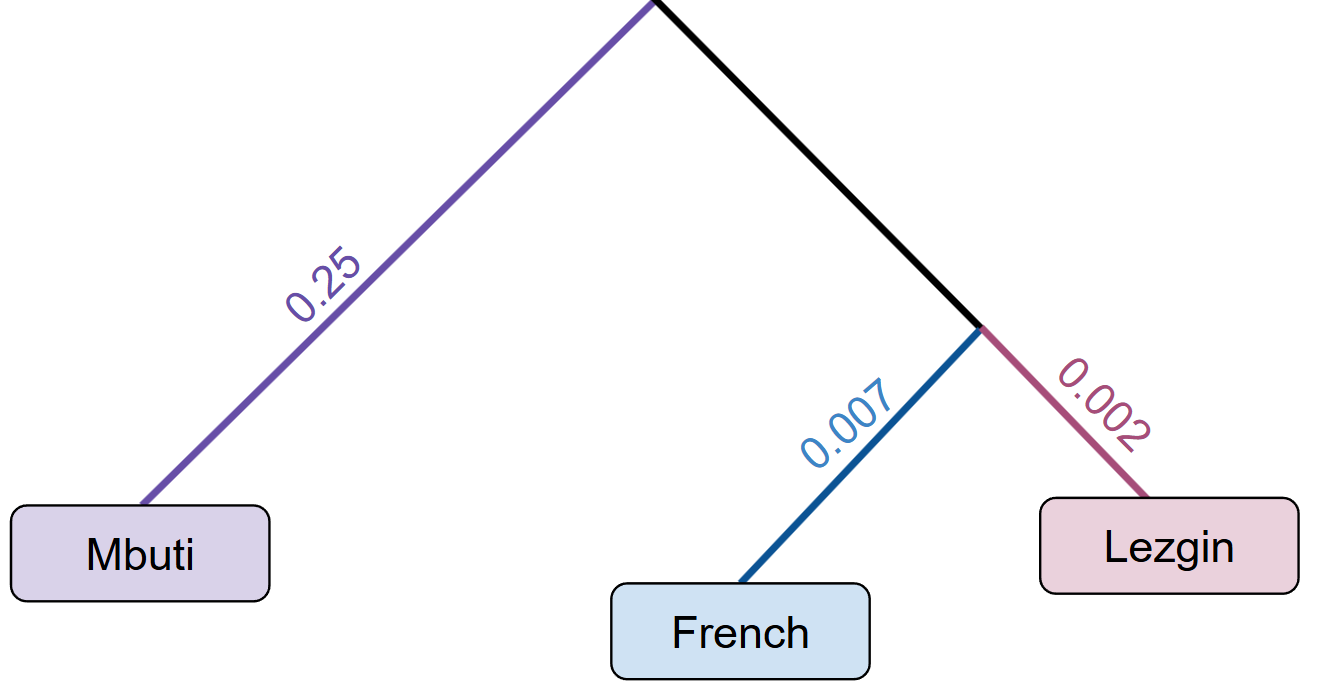

----

## 🧬 Task 3 (+1 к итоговой оценке за курс) 

Разобрать https://github.com/simonhmartin/tutorials/blob/master/ABBA_BABA_whole_genome/README.md и рассказать на защите.